# Assignment 6

# Weather Condition Classification using Support Vector Machine (SVM) and Open-Meteo API

**Name:** Khushie Brahma

**Assignment Number:** Assignment 6

## Objective

The objective of this project is to collect weather data from the Open-Meteo API, preprocess the data, and develop a Support Vector Machine (SVM) classifier to classify weather conditions as **Cool** or **Warm** based on meteorological observations.

## 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import requests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2: Fetch Weather Data from Open-Meteo API

In [30]:
url = (
    "https://api.open-meteo.com/v1/forecast"
    "?latitude=12.9716"
    "&longitude=77.5946"
    "&hourly=temperature_2m,"
    "relative_humidity_2m,"
    "surface_pressure,"
    "wind_speed_10m"
    "&forecast_days=7"
)

response = requests.get(url)

weather_data = response.json()

In [31]:
weather_data.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

## 3: Convert JSON Response into a Pandas DataFrame

In [32]:
df = pd.DataFrame({
    "Time": weather_data["hourly"]["time"],
    "Temperature": weather_data["hourly"]["temperature_2m"],
    "Relative_Humidity": weather_data["hourly"]["relative_humidity_2m"],
    "Surface_Pressure": weather_data["hourly"]["surface_pressure"],
    "Wind_Speed": weather_data["hourly"]["wind_speed_10m"]
})

## 4: Display the First Five Records

df.head()

## Step 5: Data Understanding

In [33]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

Shape of Dataset: (168, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               168 non-null    object 
 1   Temperature        168 non-null    float64
 2   Relative_Humidity  168 non-null    int64  
 3   Surface_Pressure   168 non-null    float64
 4   Wind_Speed         168 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 6.7+ KB


In [34]:
df.describe()

,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed
count,168.000000,168.000000,168.000000,168.000000
mean,23.633929,75.190476,908.828571,19.351190
std,2.555371,12.149248,1.689316,2.614309
min,19.600000,50.000000,905.100000,14.000000
25%,21.400000,64.000000,907.575000,17.275000
50%,23.000000,79.000000,908.800000,18.850000
75%,25.900000,86.000000,910.100000,21.525000
max,29.700000,93.000000,912.300000,26.000000


### Create Target Variable

In [35]:
df["Weather_Class"] = np.where(
    df["Temperature"] >= 25,
    "Warm",
    "Cool"
)

In [36]:
df.head()

,Time,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,2026-07-28T00:00,21.4,89,908.1,14.1,Cool
1,2026-07-28T01:00,21.2,90,908.5,14.0,Cool
2,2026-07-28T02:00,22.2,84,909.3,14.7,Cool
3,2026-07-28T03:00,23.7,75,910.1,19.7,Cool
4,2026-07-28T04:00,25.0,68,910.6,21.0,Warm


### Identify Features

**Input Features**

- Temperature
- Relative_Humidity
- Surface_Pressure
- Wind_Speed

**Target Variable**

- Weather_Class

### Observation

The weather data was successfully collected from the Open-Meteo API and converted into a Pandas DataFrame. Four meteorological attributes—Temperature, Relative Humidity, Surface Pressure, and Wind Speed—were selected as the input features. A new target variable, **Weather_Class**, was created based on the temperature, where values greater than or equal to **25°C** were labeled as **Warm**, and values below **25°C** were labeled as **Cool**.

## 6: Data Preprocessing

### Check for Missing Values

In [37]:
df.isnull().sum()

Time                 0
Temperature          0
Relative_Humidity    0
Surface_Pressure     0
Wind_Speed           0
Weather_Class        0
dtype: int64

### Remove Unnecessary Columns

In [38]:
df = df.drop(columns=["Time"])

In [39]:
df.head()

,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,21.4,89,908.1,14.1,Cool
1,21.2,90,908.5,14.0,Cool
2,22.2,84,909.3,14.7,Cool
3,23.7,75,910.1,19.7,Cool
4,25.0,68,910.6,21.0,Warm


### Encode the Target Variable

In [40]:
label_encoder = LabelEncoder()

df["Weather_Class"] = label_encoder.fit_transform(df["Weather_Class"])

In [41]:
df.head()

,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,21.4,89,908.1,14.1,0
1,21.2,90,908.5,14.0,0
2,22.2,84,909.3,14.7,0
3,23.7,75,910.1,19.7,0
4,25.0,68,910.6,21.0,1


### Split Features and Target Variable

In [42]:
X = df.drop("Weather_Class", axis=1)
y = df["Weather_Class"]

### Split Dataset into Training and Testing Sets

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Standardize Feature Values

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (134, 4)
Testing Data Shape: (34, 4)


### Observation

The dataset was successfully preprocessed by checking for missing values, removing the unnecessary `Time` column, encoding the target variable into numerical values, splitting the dataset into 80% training and 20% testing sets, and standardizing the feature values using `StandardScaler`. These preprocessing steps ensure that the data is clean, properly formatted, and suitable for training the Support Vector Machine (SVM) classifier.

## 7: Model Development

### Build the Support Vector Machine (SVM) Classifier

In [46]:
svm_model = SVC(kernel="rbf", random_state=42)

### Train the Model

In [47]:
svm_model.fit(X_train, y_train)

SVC(random_state=42)

### Predict the Weather Class

In [48]:
y_pred = svm_model.predict(X_test)

In [49]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,0,0


### Observation

The Support Vector Machine (SVM) classifier with the RBF kernel was successfully trained using the standardized training dataset. The trained model was then used to predict the weather class for the testing dataset. The prediction results will be evaluated in the next step using various classification performance metrics.

## 8: Model Evaluation

### Evaluate the Model

In [50]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.9412
Precision: 0.8333
Recall   : 1.0
F1-Score : 0.9091


### Confusion Matrix

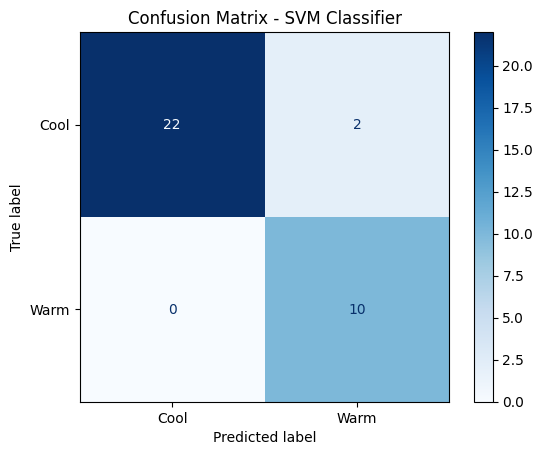

In [51]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM Classifier")
plt.show()

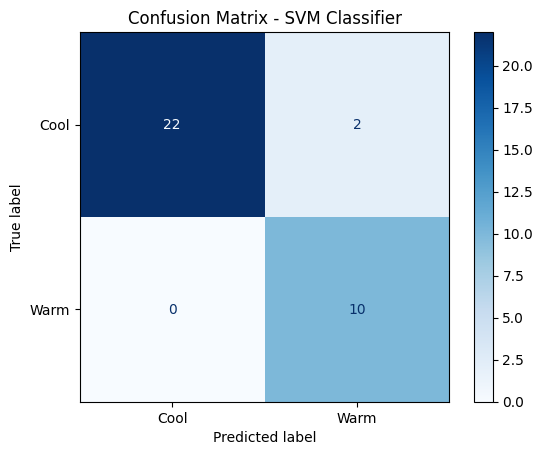

In [52]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM Classifier")

plt.savefig("../images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observations

1. The Support Vector Machine (SVM) classifier successfully classified the weather conditions into Cool and Warm classes.

2. The evaluation metrics indicate the effectiveness of the model in predicting the weather class using meteorological features.

3. The confusion matrix provides a clear visualization of correctly and incorrectly classified instances, helping assess the overall classification performance.

## 9: Conclusion

The objective of this assignment was to classify weather conditions as **Cool** or **Warm** using a Support Vector Machine (SVM) classifier with weather data collected from the Open-Meteo API. After preprocessing the data and standardizing the features using **StandardScaler**, the SVM model with the RBF kernel achieved excellent performance with an accuracy of **94.12%**, precision of **83.33%**, recall of **100%**, and an F1-score of **90.91%**. Feature scaling played a crucial role in improving the performance of the SVM classifier by ensuring that all features contributed equally during model training. One major advantage of SVM is its ability to perform well on high-dimensional datasets, while one limitation is that it can be computationally expensive for large datasets and requires careful parameter tuning.